# Khám Phá & Trực Quan Hóa Dữ Liệu (Exploratory Data Analysis)

Notebook này tổng hợp quá trình phân tích dữ liệu (EDA), phân bố nhãn, các kỹ thuật Data Augmentation, và toàn bộ các kỹ thuật trích xuất đặc trưng truyền thống và hiện đại nhất để phân biệt ảnh thật (Real) và ảnh giả mạo (Spoof).

In [2]:
import os
import sys
import random
import numpy as np

import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

from skimage.feature import local_binary_pattern, hog
from skimage.filters import difference_of_gaussians

sys.path.append(os.path.abspath('..'))
from src.data import get_data_stats

dataset_root = "../datasets/LCC_FASD"

## 1. Khởi tạo và Phân bố Dữ liệu
---

In [3]:
paths, class_names, data_stats = get_data_stats(dataset_root)

print("Đường dẫn các tập dữ liệu:")
for split, path in paths.items():
    print(f"- {split}: {path}")

print(f"\nCác nhãn: {class_names}")

print("\nPhân bổ dữ liệu trong các tập:")
for split, stats in data_stats.items():
    print(f"\nTập {split}:")
    for class_name, count in stats.items():
        print(f"  - {class_name}: {count} ảnh")

Đường dẫn các tập dữ liệu:
- train: ../datasets/LCC_FASD/train
- val: ../datasets/LCC_FASD/val
- test: ../datasets/LCC_FASD/test

Các nhãn: ['real', 'spoof']

Phân bổ dữ liệu trong các tập:

Tập train:
  - real: 1223 ảnh
  - spoof: 7076 ảnh

Tập val:
  - real: 405 ảnh
  - spoof: 2543 ảnh

Tập test:
  - real: 314 ảnh
  - spoof: 7266 ảnh


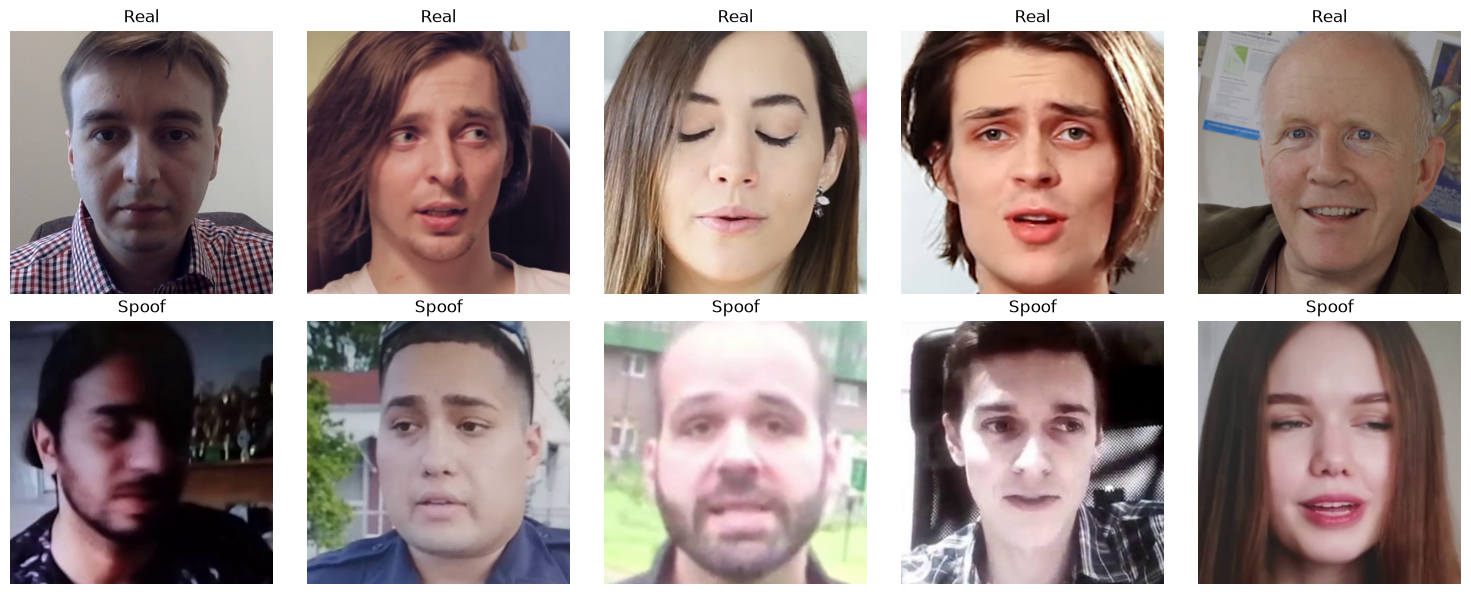

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

real_dir = os.path.join(paths['train'], 'real')
spoof_dir = os.path.join(paths['train'], 'spoof')

real_imgs = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
spoof_imgs = [os.path.join(spoof_dir, f) for f in os.listdir(spoof_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

for i in range(5):
    # Real
    img_real = tf.keras.utils.load_img(random.choice(real_imgs))
    axes[0, i].imshow(img_real)
    axes[0, i].set_title("Real")
    axes[0, i].axis('off')

    # Spoof
    img_spoof = tf.keras.utils.load_img(random.choice(spoof_imgs))
    axes[1, i].imshow(img_spoof)
    axes[1, i].set_title("Spoof")
    axes[1, i].axis('off')
    
plt.tight_layout()
plt.show()

## 2. Phân tích Nhãn (Class Imbalance)
---

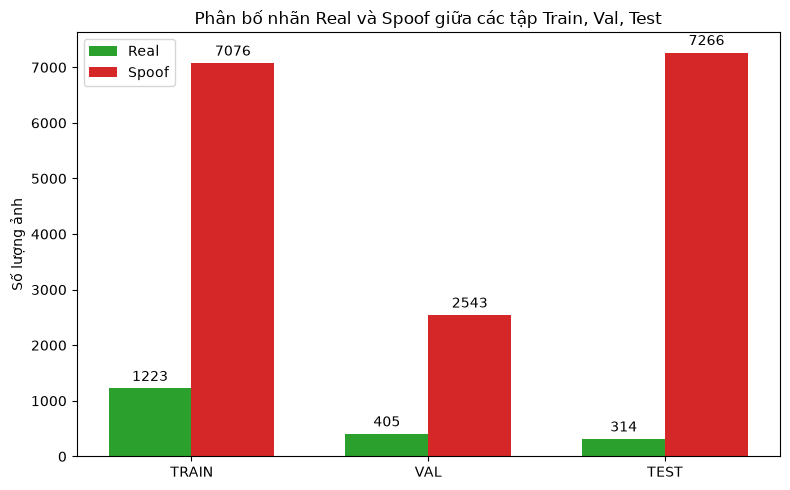

In [5]:
splits = list(data_stats.keys())
real_counts = [data_stats[s]['real'] for s in splits]
spoof_counts = [data_stats[s]['spoof'] for s in splits]

x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, real_counts, width, label='Real', color='#2ca02c')
rects2 = ax.bar(x + width/2, spoof_counts, width, label='Spoof', color='#d62728')

ax.set_ylabel('Số lượng ảnh')
ax.set_title('Phân bố nhãn Real và Spoof giữa các tập Train, Val, Test')
ax.set_xticks(x)
ax.set_xticklabels([split.upper() for split in splits])
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.tight_layout()
plt.show()

Tập dữ liệu huấn luyện đang bị mất cân bằng nhãn trầm trọng khi số lượng ảnh giả mạo (spoof) áp đảo gấp gần 6 lần ảnh thật (real), đòi hỏi quy trình huấn luyện phải tích hợp các kỹ thuật cân bằng dữ liệu như `WeightedRandomSampler` hoặc sử dụng hàm mất mát `Focal Loss` để ngăn chặn mô hình học thiên lệch.

## 3. Kỹ thuật Tiền xử lý (Data Augmentation)
---

In [6]:
def random_sample_images(data_dir, class_names, num_samples):
    sampled_images = []
    for class_name in class_names:
        class_dir = os.path.join(data_dir, class_name)
        images = [os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
        sampled_images.extend(random.sample(images, min(num_samples, len(images))))
    return sampled_images

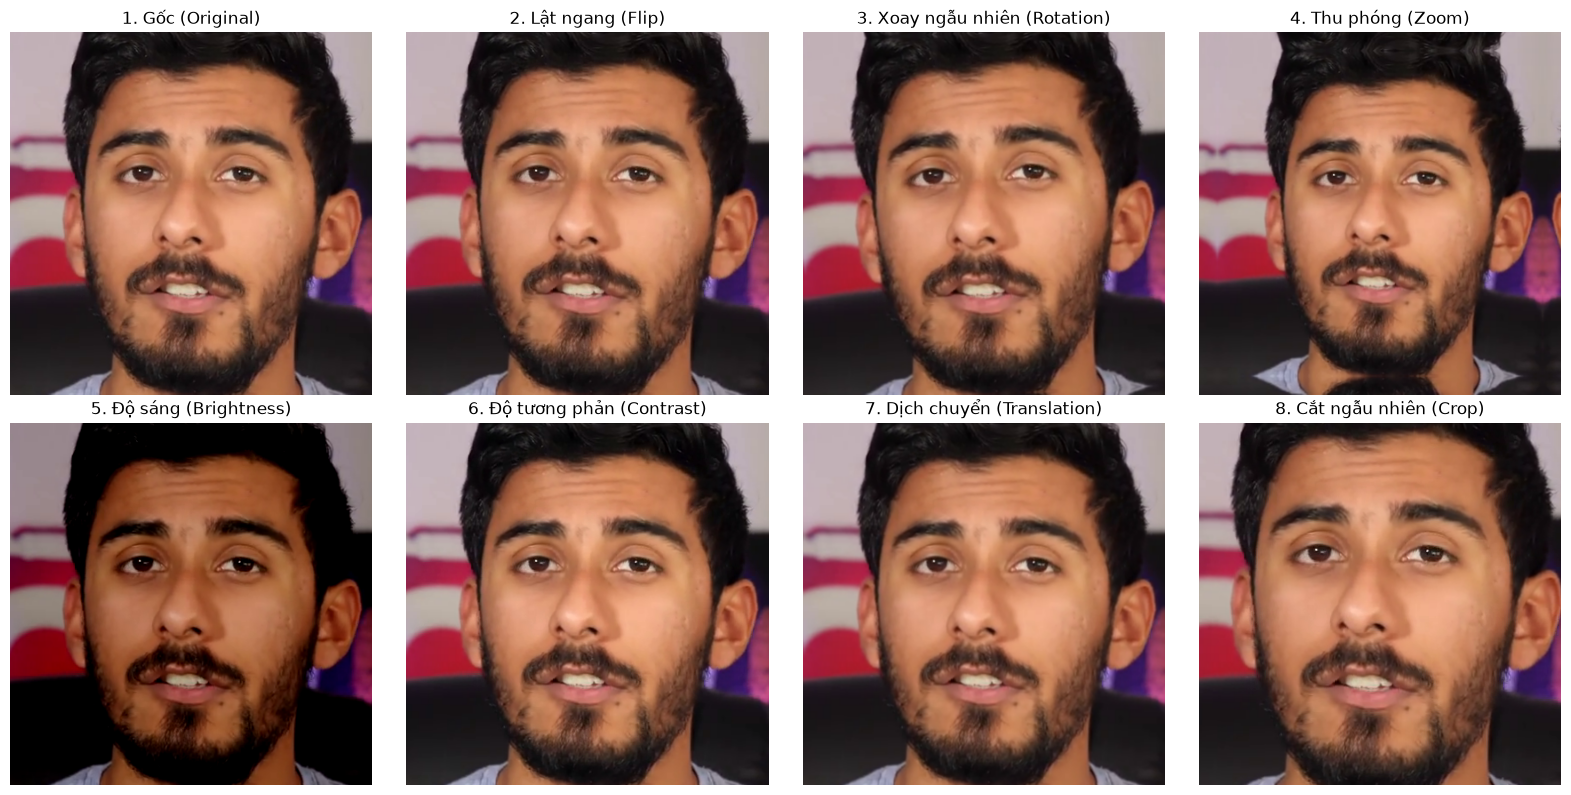

In [19]:
# Chọn ngẫu nhiên 1 ảnh Real để làm mẫu augmentation
sample_img_path = random.choice(random_sample_images(paths['train'], class_names, num_samples=1))
img = tf.keras.utils.load_img(sample_img_path)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

# Định nghĩa 7 loại Data Augmentation (không chứa lớp rỗng)
data_augmentation_layers = {
    "2. Lật ngang (Flip)": tf.keras.Sequential([tf.keras.layers.RandomFlip("horizontal")]),
    "3. Xoay ngẫu nhiên (Rotation)": tf.keras.Sequential([tf.keras.layers.RandomRotation(0.05)]),
    "4. Thu phóng (Zoom)": tf.keras.Sequential([tf.keras.layers.RandomZoom(0.2)]),
    "5. Độ sáng (Brightness)": tf.keras.Sequential([tf.keras.layers.RandomBrightness(0.2)]),
    "6. Độ tương phản (Contrast)": tf.keras.Sequential([tf.keras.layers.RandomContrast(0.2)]),
    "7. Dịch chuyển (Translation)": tf.keras.Sequential([tf.keras.layers.RandomTranslation(0.01, 0.01)]),
    "8. Cắt ngẫu nhiên (Crop)": tf.keras.Sequential([tf.keras.layers.RandomCrop(int(img_array.shape[1]*0.9), int(img_array.shape[2]*0.9))])
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

axes[0].imshow(img_array[0].numpy().astype("uint8"))
axes[0].set_title("1. Gốc (Original)")
axes[0].axis('off')

for i, (name, aug_layer) in enumerate(data_augmentation_layers.items(), start=1):
    # Áp dụng Augmentation (training=True để kích hoạt các Random layer)
    augmented_image = aug_layer(img_array, training=True)
    axes[i].imshow(augmented_image[0].numpy().astype("uint8"))
    axes[i].set_title(name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Nhận xét:

Mặc dùng cơ chế `Augmentation` giúp tăng khả năng chống overfitting nhưng nhiều loại sẽ khiến cho mô hình khó phân biệt được giữa 2 nhãn `real` và `spoof` khi cường độ quá mạnh. Do đó chúng tôi quyết định sử dụng mức dộ đã tinh chỉnh để kiểm soát biến động ảnh và đồng thời bỏ đi một vài phép biến đổi như `Crop` ngẫu nhiên do mất phần lớn khuôn mặt hoặc tăng tham số của phép crop mặt lên, và đồng thời sử dụng cơ chế `random` cho mỗi lần thực hiện augmentation.

## 4. Trích Xuất Đặc Trưng (Feature Extraction)
---

In [8]:
real_path = random.choice(random_sample_images(paths['train'], ['real'], num_samples=1))
spoof_path = random.choice(random_sample_images(paths['train'], ['spoof'], num_samples=1))

### 4.1. Phân Tích Đa Không Gian Màu (Multi-Color Space Analysis)

---

Nhiều đặc trưng rò rỉ ánh sáng từ màn hình điện thoại (Spoof) không hiển thị rõ trên dải RGB. Việc phân rã ra các hệ màu độc lập như độ sáng (Y, V), màu sắc (H), đỏ/xanh (Cr, Cb) giúp dễ dàng bắt được các vệt nhiễu màu này.

In [9]:
# Hàm tải ảnh và gom nhóm 3 hàng: Gộp (RGB, YCrCb, HSV), Tách (Y, Cr, Cb) và Tách (H, S, V)
def get_channels(path):
    img = tf.keras.utils.img_to_array(tf.keras.utils.load_img(path)).astype("uint8")
    y, cr, cb = cv2.split(cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb))
    h, s, v = cv2.split(cv2.cvtColor(img, cv2.COLOR_RGB2HSV))
    return [[img, cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb), cv2.cvtColor(img, cv2.COLOR_RGB2HSV)], [y, cr, cb], [h, s, v]]

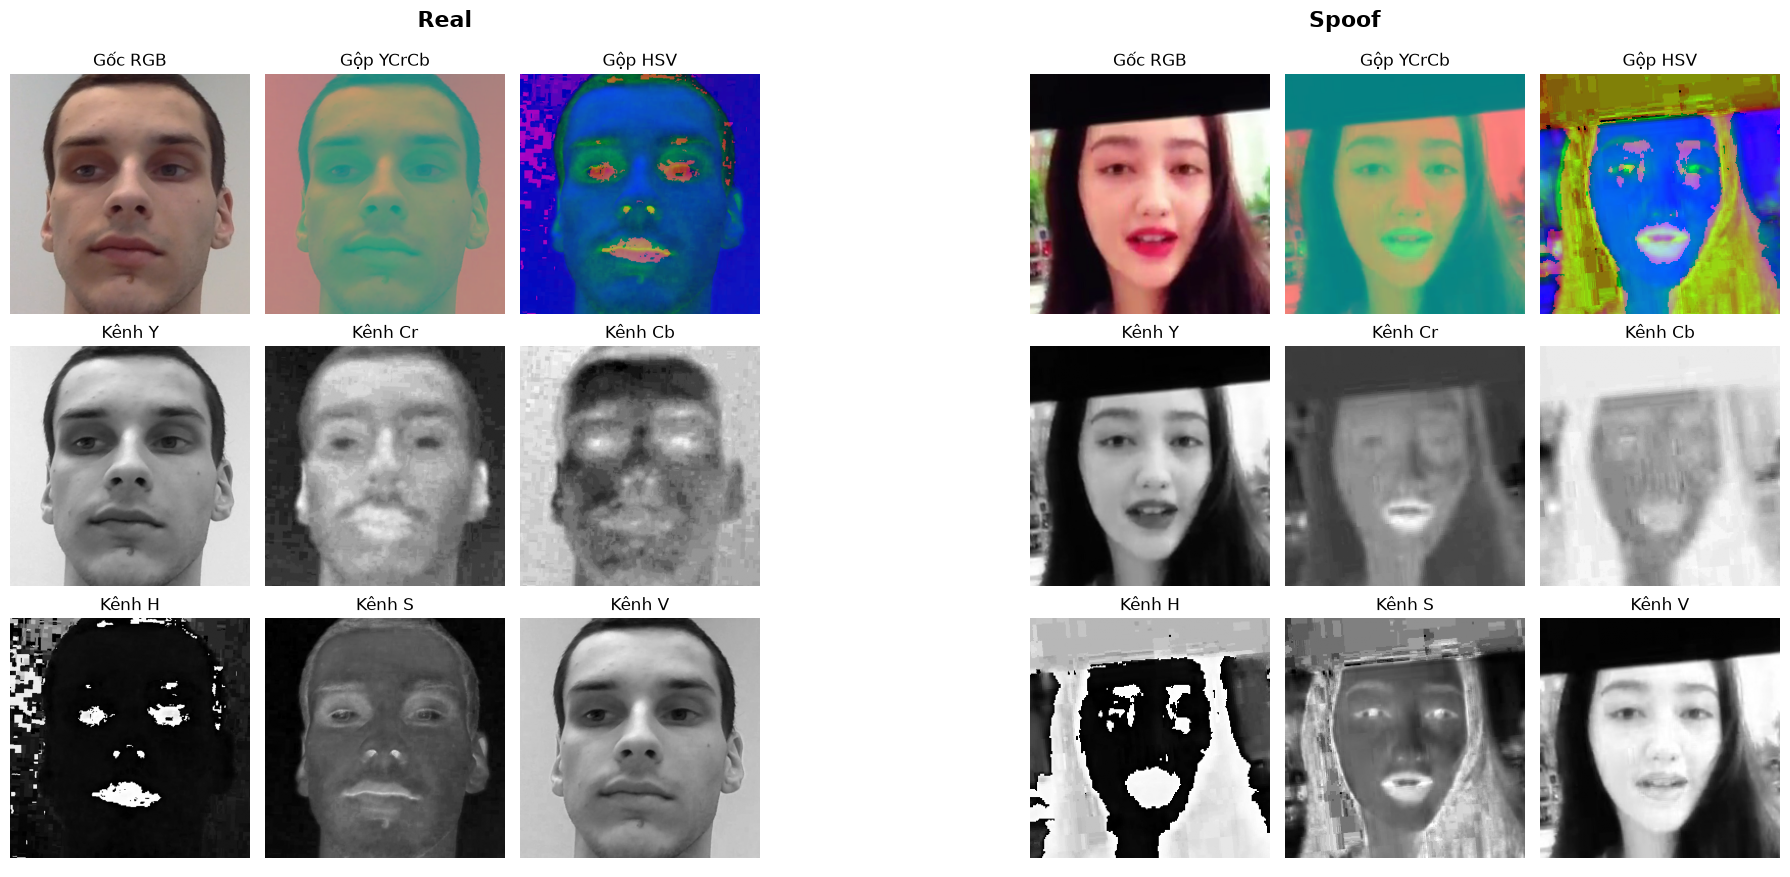

In [10]:
real_data = get_channels(real_path)
spoof_data = get_channels(spoof_path)

titles = [["Gốc RGB", "Gộp YCrCb", "Gộp HSV"], ["Kênh Y", "Kênh Cr", "Kênh Cb"], ["Kênh H", "Kênh S", "Kênh V"]]

fig, axes = plt.subplots(3, 7, figsize=(18, 9))
fig.text(0.25, 0.95, "Real", fontsize=16, fontweight='bold', ha='center')
fig.text(0.75, 0.95, "Spoof", fontsize=16, fontweight='bold', ha='center')

# Vòng lặp vẽ ảnh
for r in range(3):
    axes[r, 3].axis('off') # Ẩn hoàn toàn cột ở giữa
    
    for c in range(3):
        cmap = None if r == 0 else 'gray'
        axes[r, c].imshow(real_data[r][c], cmap=cmap)
        axes[r, c].set_title(titles[r][c])
        axes[r, c].axis('off')
        axes[r, c+4].imshow(spoof_data[r][c], cmap=cmap)
        axes[r, c+4].set_title(titles[r][c])
        axes[r, c+4].axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.93]) 
plt.show()

### 4.2. Trích Xuất Vi Kết Cấu (Micro-Texture & Structure)

---

Các bề mặt in ấn hay màn hình led đều có kết cấu rỗ, sắc cạnh khác biệt hoàn toàn với da người.
- **LBP (Local Binary Pattern):** Nhìn cấu trúc rỗ siêu nhỏ.
- **DoG (Difference of Gaussians):** Làm rõ nét cạnh viền và cấu trúc khối.
- **HOG (Histogram of Oriented Gradients):** Nhìn tổng thể cấu trúc hình học xem có góc cạnh nhân tạo nào không.

In [11]:
# Hàm đọc ảnh xám và trích xuất 3 loại đặc trưng vi kết cấu
def extract_texture_features(img_path):
    gray = tf.keras.utils.img_to_array(tf.keras.utils.load_img(img_path, color_mode="grayscale"))[:, :, 0].astype("uint8")
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    dog = difference_of_gaussians(gray, low_sigma=1, high_sigma=2)
    _, hog_img = hog(gray, visualize=True)
    return [gray, lbp, dog, hog_img]

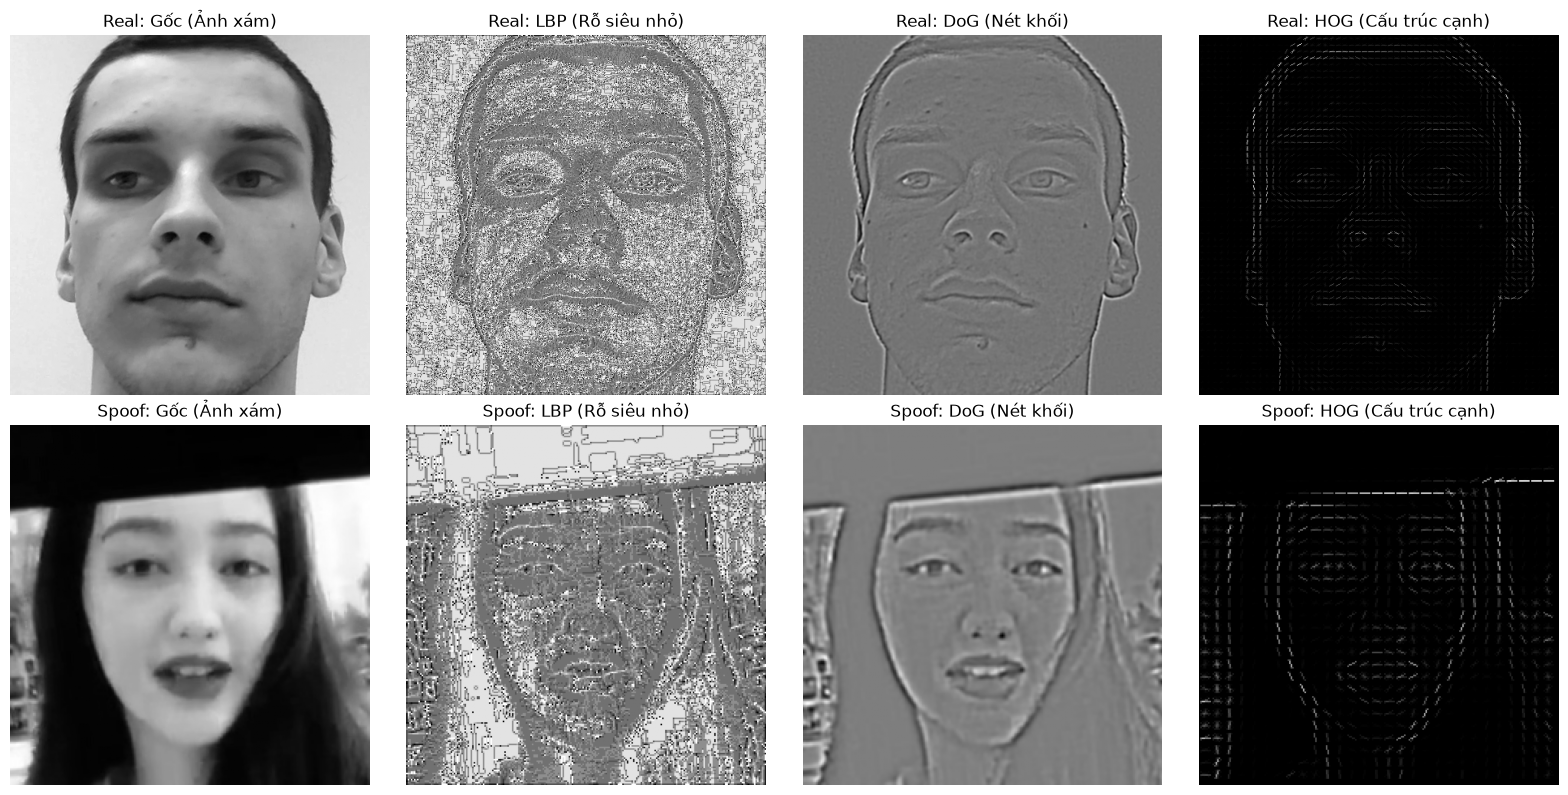

In [12]:
real_features = extract_texture_features(real_path)
spoof_features = extract_texture_features(spoof_path)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
titles = ["Gốc (Ảnh xám)", "LBP (Rỗ siêu nhỏ)", "DoG (Nét khối)", "HOG (Cấu trúc cạnh)"]

for c in range(4):
    axes[0, c].imshow(real_features[c], cmap='gray')
    axes[0, c].set_title(f"Real: {titles[c]}")
    axes[0, c].axis('off')
    axes[1, c].imshow(spoof_features[c], cmap='gray')
    axes[1, c].set_title(f"Spoof: {titles[c]}")
    axes[1, c].axis('off')

plt.tight_layout()
plt.show()

### 4.3. Trích Xuất Nhiễu & Tần Số Chuyên Sâu (Noise & Frequency Analysis)

---

- **FFT (Fourier Transform):** Màn hình hay máy in hay tạo ra vân Moiré, sẽ xuất hiện dưới dạng các chấm sáng chói đối xứng trong phổ FFT.
- **SRM (Spatial Rich Model):** Bằng cách dùng các lõi lọc đặc biệt, SRM triệt tiêu toàn bộ khuôn mặt, chỉ chừa lại đúng vết xước màn hình, vệt nén JPEG, hay hạt mực.

In [13]:
# Định nghĩa lõi lọc SRM cơ bản (triệt tiêu vùng phẳng, làm nổi bật nhiễu hạt)
srm_kernel = np.array([[-1, 2, -1], [2, -4, 2], [-1, 2, -1]]) / 4.0

# Hàm trích xuất Phổ FFT và Nhiễu SRM
def extract_noise_freq(img_path):
    gray = tf.keras.utils.img_to_array(tf.keras.utils.load_img(img_path, color_mode="grayscale"))[:, :, 0]
    
    # Tính phổ FFT (Chuyển đổi Fourier 2D) và dịch tâm về giữa
    fft_mag = 20 * np.log(np.abs(np.fft.fftshift(np.fft.fft2(gray))) + 1)
    
    # Tính ảnh nhiễu SRM (Dùng OpenCV áp lõi lọc SRM 3x3)
    srm_img = cv2.filter2D(gray, -1, srm_kernel)
    
    return [gray, fft_mag, srm_img]

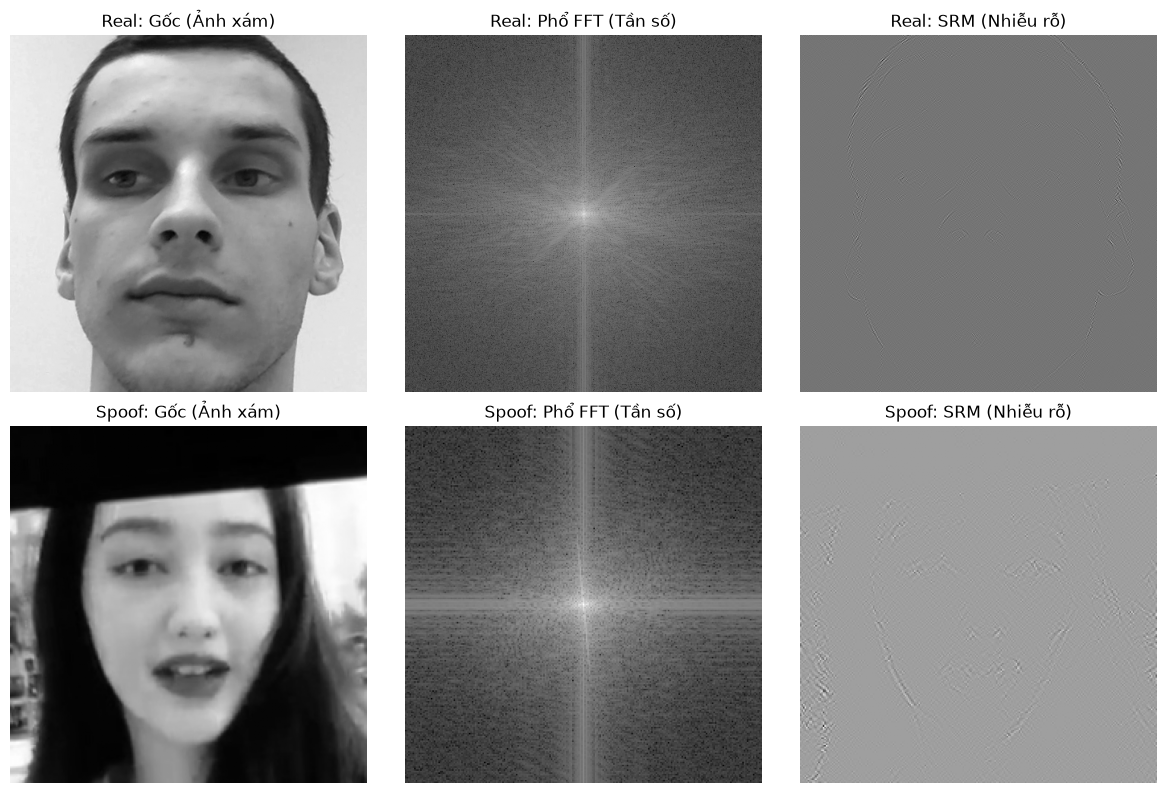

In [14]:
# Trích xuất cho 1 ảnh Real và 1 ảnh Spoof
real_nf = extract_noise_freq(real_path)
spoof_nf = extract_noise_freq(spoof_path)

# Tạo lưới 2 hàng x 3 cột
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
titles = ["Gốc (Ảnh xám)", "Phổ FFT (Tần số)", "SRM (Nhiễu rỗ)"]

# Vòng lặp vẽ ảnh
for c in range(3):
    # Real
    axes[0, c].imshow(real_nf[c], cmap='gray')
    axes[0, c].set_title(f"Real: {titles[c]}")
    axes[0, c].axis('off')
    
    # Spoof
    axes[1, c].imshow(spoof_nf[c], cmap='gray')
    axes[1, c].set_title(f"Spoof: {titles[c]}")
    axes[1, c].axis('off')

plt.tight_layout()
plt.show()

### 4.4. Ước Lượng Hình Học 3D (Monocular Depth Estimation)

---

Khuôn mặt thật có độ khối 3D. Màn hình điện thoại và ảnh in là mặt phẳng 2D.

In [ ]:
import tensorflow_hub as hub

midas = hub.load("https://tfhub.dev/intel/midas/v2_1_small/1", tags=['serve'])

def get_depth_map(img_path):
    img = tf.keras.utils.img_to_array(tf.keras.utils.load_img(img_path))           # Đọc ảnh RGB
    
    input_tensor = tf.expand_dims(tf.image.resize(img, [256, 256]) / 255.0, 0)     # Chuẩn hóa và resize ảnh về 256x256
    input_tensor = tf.transpose(input_tensor, [0, 3, 1, 2])                        # Chuyển đổi sang định dạng [batch, channels, height, width] để phù hợp với mô hình MiDaS
    
    depth = midas.signatures['serving_default'](input_tensor)['default'][0]        # Dự đoán bản đồ độ sâu
    depth_resized = tf.image.resize(tf.expand_dims(depth, -1), [img.shape[0], img.shape[1]]) # Resize bản đồ độ sâu về kích thước gốc của ảnh
    
    return [img.astype("uint8"), depth_resized.numpy()[:, :, 0]] # Trả về ảnh gốc và bản đồ độ sâu

INFO:tensorflow:Saver not created because there are no variables in the graph to restore


INFO:tensorflow:Saver not created because there are no variables in the graph to restore


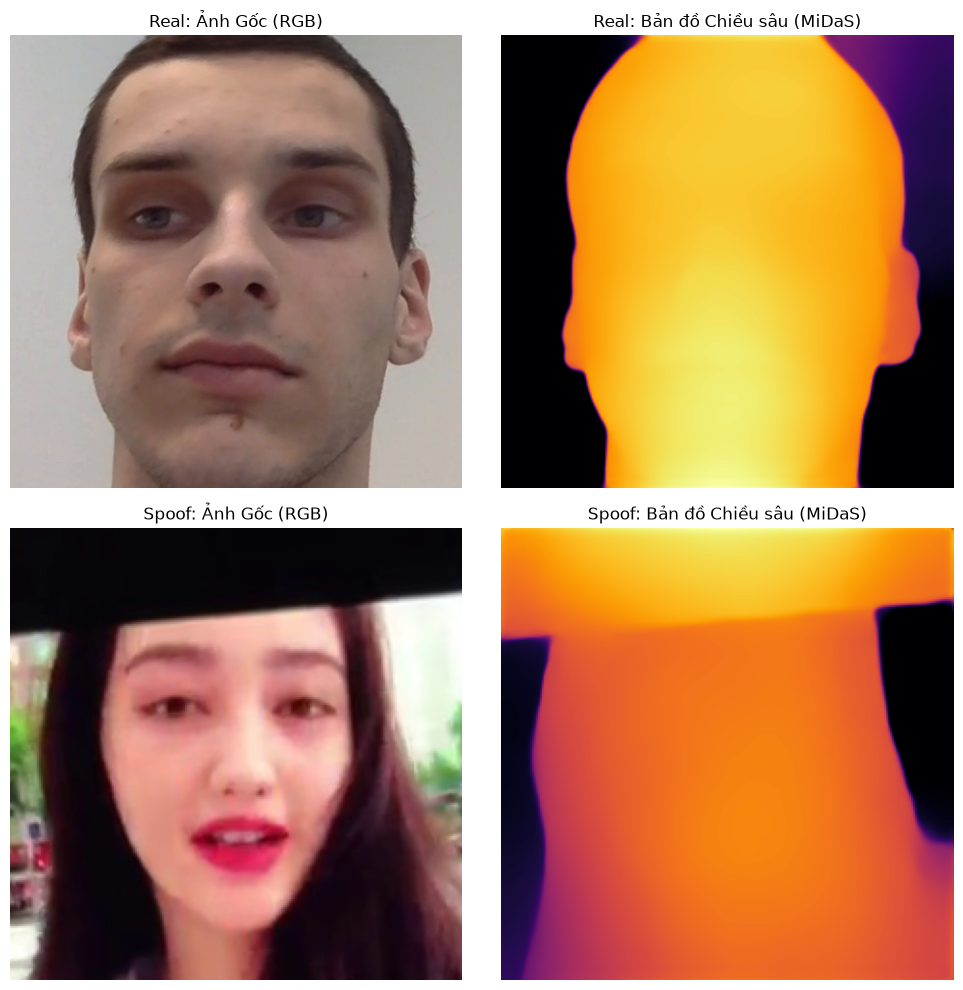

In [16]:
real_depth = get_depth_map(real_path)
spoof_depth = get_depth_map(spoof_path)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
titles = ["Ảnh Gốc", "Bản đồ Chiều sâu"]

for r, data in enumerate([real_depth, spoof_depth]):
    for c in range(2):
        cmap = None if c == 0 else 'inferno'
        axes[r, c].imshow(data[c], cmap=cmap)
        axes[r, c].set_title(f"{'Real' if r==0 else 'Spoof'}: {titles[c]}")
        axes[r, c].axis('off')

plt.tight_layout()
plt.show()

### Nhận xét:

Qua việc trích xuất thêm một vài đặc trưng, chúng tôi nhận thấy rằng phần lớn các đặc trưng được trích xuất từ 2 ảnh `real` và `spoof` có một sự khác biệt nhấn định. Điều này có thể giúp chúng tôi xây dựng một mô hình nhận diện quét mặt gian lận tốt hơn thay vì chỉ dựa vào 3 kênh màu ảnh của RBG. Tuy nhiên, chúng tôi đã đặt ra giả thuyết rằng việc áp dụng thêm bản đồ chiều sâu, độ sâu của ảnh sẽ giúp mô hình cải thiện hơn nữa bằng việc sử dụng mô hình chiều sâu `MiDas` nhằm giám sát và huấn luyên phụ cho mô hình nhưng mô hình `MiDas` hiện tại đã không đạt đủ điều kiện khi toàn bộ bức ảnh spoof chúng đều nhận diện rằng đó là gương mặt 3D.

## Kết luận

---

Dựa trên những gì đã khám phá, chúng tôi đã hiểu rõ dữ liệu. Đây là một bộ dữ liệu thực tế khi camera và góc độ chụp của mỗi người là khác nhau cùng với môi trường và địa điểm, điều kiện ánh sáng, ... Vì vậy cần một mô hình tinh vi nhằm học được bản chất các đặc điểm gian lận thay vì là học đặc điểm khuôn mặt hay môi trường và ánh sáng. Điều đặc biệt là toàn bộ bức ảnh đều đã được crop vào khuôn mặt, điều này khiến chúng tôi bớt việc phải xây dựng lại mô hình nhận diện khuôn mặt. 

Mặc dù chúng tôi sẽ không phải xây dựng lại mô hình nhận diện khuôn mặt, tuy nhiên theo như quan sát và khám phá, chúng tôi nhận thấy rằng bộ dữ liệu này có nhiều ảnh nhiễu không phải khuôn mặt, điều này sẽ dẫn đến việc gây nhiễu và làm hỏng mô hình. Trong notebook tiếp theo chúng tôi sẽ đi kiểm tra dữ liệu trước khi đi vào xây dựng mô hình.

Vấn đề về lệch nhãn chúng tôi sẽ xử lý bằng `WeightSampler` nhằm vừa tạo độ đa dạng cho ảnh, đặc biệt là `real`, kết hợp việc lấy mẫu cho mỗi batch dựa trên độ lệch nhãn sẽ giúp vừa xử lý được vấn đề lệch dữ liệu vừa chống overfitting. Và chúng tôi sẽ không sử dụng `class_weights` trong hàm loss của `CrossEntropy` hay `Focal Loss` với tham số `alpha` vì sẽ bị lệch nhãn trở lại. Tuy nhiên chúng tôi vẫn cân nhắc tham số `gamma` của `Focal Loss` để mô hình tập trung vào các ảnh khó.

Bước tiếp theo của chúng tôi sẽ xây dựng mô hình `baseline` để kiểm chứng hàm loss, `weight_decays` hay `label_smoothings`, ... để cải thiện mô hình, và tích hợp thêm một vài bước dò `learning_rate` riêng cho từng mô hình.

Các đặc trưng được trích xuất thêm trong notebook này sẽ được sử dụng trong mô hình `Multi-Branch Model` nhằm coi đó là những dấu hiệu phụ để mô hình có thể nhận diện chính xác hơn.